# House Price Analysis in King County, USA
The real estate market is influenced by many factors such as property size, number of bedrooms, location features, and year of construction. This project analyzes housing data from **King County, USA**, using **Python** in a **Jupyter Notebook environment**. The aim of the analysis is to explore the dataset, clean and prepare the data, and identify the key factors that influence house prices. Using Python libraries such as **Pandas, NumPy, Matplotlib, and Seaborn**, the dataset was examined for missing values, data types, and relationships between variables. Through exploratory data analysis (EDA), the project provides insights into how different housing features relate to property prices.

### 1. Data Loading and Initial Inspection

The analysis began by importing essential Python libraries and loading **the King County housing** dataset from a **CSV file** into a **DataFrame**.
An initial inspection of the dataset showed:
* **21,597 records**
* **21 columns**

The dataset contains several property-related attributes including:
* Number of bedrooms
* Number of bathrooms
* Living area square footage
* Lot size
* Year built
* Location coordinates
* House price

This first step helped provide an overview of the dataset structure and allowed the identification of potential

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\kingcounty_house_data.csv")

In [16]:
df.head(5)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,10/13/2014,221900.0,3,1.00,1180,5650,1.0,0.0,0.0,3,7,1180,0.0,1955,0.0,98178,47.5112,-122.257,1340,5650
1,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0.0,0.0,3,7,2170,400.0,1951,1991.0,98125,47.7210,-122.319,1690,7639
2,2/25/2015,180000.0,2,1.00,770,10000,1.0,0.0,0.0,3,6,770,0.0,1933,0.0,98028,47.7379,-122.233,2720,8062
3,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0.0,0.0,5,7,1050,910.0,1965,0.0,98136,47.5208,-122.393,1360,5000
4,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0.0,0.0,3,8,1680,0.0,1987,0.0,98074,47.6168,-122.045,1800,7503


# Data Wrangling
A significant part of the project focused on data wrangling to ensure the dataset was clean and reliable for analysis.

#### Missing Values

Several variables contained missing values, including:
| Column | Missing Values| 
| :--- | :----: | 
| Waterfront | 2,376|  
| View | 63| 
| Yr_renovated| 3,842|  

Handling these missing values was necessary to avoid errors or bias in the analysis.

# Types of Data in the Dataset
### Categorical data: 
This represents characteristics or qualities that cannot be measured by numbers. 
<br>**Nominal**: Categories with no inherent order or ranking. **Examples**: Neighborhood names, color of a house, or whether a house has a waterfront (Yes/No).</br> 

**Ordinal**: Categories that have a specific, logical order or rank. **Examples:** The condition or grade columns in your dataset (e.g., 1 to 10 scale), or "Small, Medium, Large."

### Numerical data:
This represents variables that can be measured or counted.

**Discrete**: Values that are distinct and separate (usually whole numbers/counts). You can't have a "half" of these in most contexts. **Examples:** bedrooms, bathrooms, or floors.

**Continuous**: Values that can take any value within a range and can be measured with great precision. **Examples:** price, sqft_living, or the exact latitude/longitude coordinates.

## Basic Pandas Functions Used in the Analysis

### df.describe()

This provides a **statistical summary** of all numerical columns. It calculates:

* **Count**: Number of non-empty values.

* **Mean/Std**: The average and the spread (Standard Deviation).

* **Min/Max**: The range of the data.

* **Percentiles**: 25%, 50% (Median), and 75%.

In [6]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19221.000000,21534.000000,21597.000000,21597.000000,21597.000000,21597.000000,17755.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,4.580474e+09,5.402966e+05,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007596,0.233863,3.409825,7.657915,1788.596842,1970.999676,83.636778,98077.951845,47.560093,-122.213982,1986.620318,12758.283512
std,2.876736e+09,3.673681e+05,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086825,0.765686,0.650546,1.173200,827.759761,29.375234,399.946414,53.513072,0.138552,0.140724,685.230472,27274.441950
min,1.000102e+06,7.800000e+04,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,370.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### df.describe(include="all") 
It shows statistics for not only **numeric columns**, but  categorical, and object columns

In [7]:
df.describe(include = "all")

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,21597,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19221.000000,21534.000000,...,21597.000000,21597.000000,21597,21597.000000,17755.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,6/23/2014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,12826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580474e+09,NaN,5.402966e+05,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007596,0.233863,...,7.657915,1788.596842,NaN,1970.999676,83.636778,98077.951845,47.560093,-122.213982,1986.620318,12758.283512
std,2.876736e+09,NaN,3.673681e+05,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086825,0.765686,...,1.173200,827.759761,NaN,29.375234,399.946414,53.513072,0.138552,0.140724,685.230472,27274.441950
min,1.000102e+06,NaN,7.800000e+04,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,...,3.000000,370.000000,NaN,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,NaN,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,NaN,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,NaN,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


### df.shape

It is a Pandas Data-Frame attribute that tells you the size (dimensions) of the dataset.
It returns a tuple in this format:
(number_of_rows, number_of_columns)

In [8]:
df.shape

(21597, 21)

## 1. Display the date types using dtypes.

### df.dtypes** 
This is used in pandas to show the data type of each column in a DataFrame. It quickly tells you what kind of data each column.

In [9]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement     object
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [10]:
df['yr_renovated']

0           0.0
1        1991.0
2           NaN
3           0.0
4           0.0
          ...  
21592       0.0
21593       0.0
21594       0.0
21595       0.0
21596       0.0
Name: yr_renovated, Length: 21597, dtype: float64

In [11]:
df['waterfront']

0        NaN
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
21592    0.0
21593    0.0
21594    0.0
21595    NaN
21596    0.0
Name: waterfront, Length: 21597, dtype: float64

### .fillna(0)
In pandas, it is used to replace missing values (NaN) with 0.

Missing values in the waterfront and view columns were filled with 0, assuming the absence of waterfront or view features. Missing values in yr_renovated were also replaced with 0, indicating that the property had not been renovated.

In [12]:
df['yr_renovated']= df['yr_renovated'].fillna(0)

In [13]:
df['waterfront']= df['waterfront'].fillna(0)

In [12]:
df['view']= df['view'].fillna(df['view'].mode()[0])

### df.isnull().sum()
In pandas, it is used to count the number of missing values (NaN) in each column of a DataFrame or check whether the missing data has been filled.

In [14]:
df.isnull().sum()

id                0
date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view             63
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

### df.drop 
This is a method used to remove rows or columns from a DataFrame.

When you "drop" data, you aren't just hiding it; you are creating a new version of the DataFrame (or modifying the current one) that excludes the specific labels you've identified.

In [29]:
df.drop(['id'], axis=1, inplace = True)

KeyError: "['id'] not found in axis"

## Exploratory Data Analysis
EDA stands for Exploratory Data Analysis. It is the most critical step in any data project—it's the process of "interrogating" your data to find patterns, spot anomalies, and check assumptions before you start building models.

Think of it like a detective investigating a crime scene before making an arrest.

The EDA Workflow in Python Most professionals use a "Big Three" stack: Pandas (for structure), Matplotlib/Seaborn (for visuals), and NumPy (for math).

 ## 2. Use the method value counts to count the number of houses with unique floor use the method to frame () to convert it to a dataframe.m


### Value count
In pandas is used to count how many times each value appears in a data frame.

In [ ]:
df['floors'].value_counts(). to_frame()

## 3. Is there a postive or negative correlation between the number of bedrom and the price of the house


### corr
In pandas, the correlation function is used to find how strongly numerical columns are related to each other.

In [18]:
correlation = df['bedrooms'].corr(df['price'])


In [19]:
x=np.round(correlation,5)
x

np.float64(0.30879)

## 4. Are there any trends in house prices over the years based on the "yr-bulit" variable? How would you visualise the trend.


In [20]:
df.dtypes

date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement     object
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [21]:
df['yr_built'].dtypes

dtype('int64')

In [22]:
df['yr_built']= df['yr_built'].astype('datetime64[ns]')

In [23]:
df['yr_built'].dtypes

dtype('<M8[ns]')

<h4>The average house price in King County is approximately $540,296, but the large standard deviation indicates significant variability in property prices.</h4>

In [24]:
median_prices = df.groupby('yr_built')['price'].median().reset_index()

In [25]:
median_prices

,yr_built,price
0,1970-01-01 00:00:00.000001900,549000.0
1,1970-01-01 00:00:00.000001901,550000.0
2,1970-01-01 00:00:00.000001902,624000.0
3,1970-01-01 00:00:00.000001903,461000.0
4,1970-01-01 00:00:00.000001904,478000.0
...,...,...
111,1970-01-01 00:00:00.000002011,440000.0
112,1970-01-01 00:00:00.000002012,448475.0
113,1970-01-01 00:00:00.000002013,565000.0
114,1970-01-01 00:00:00.000002014,599000.0


<Figure size 640x480 with 0 Axes>

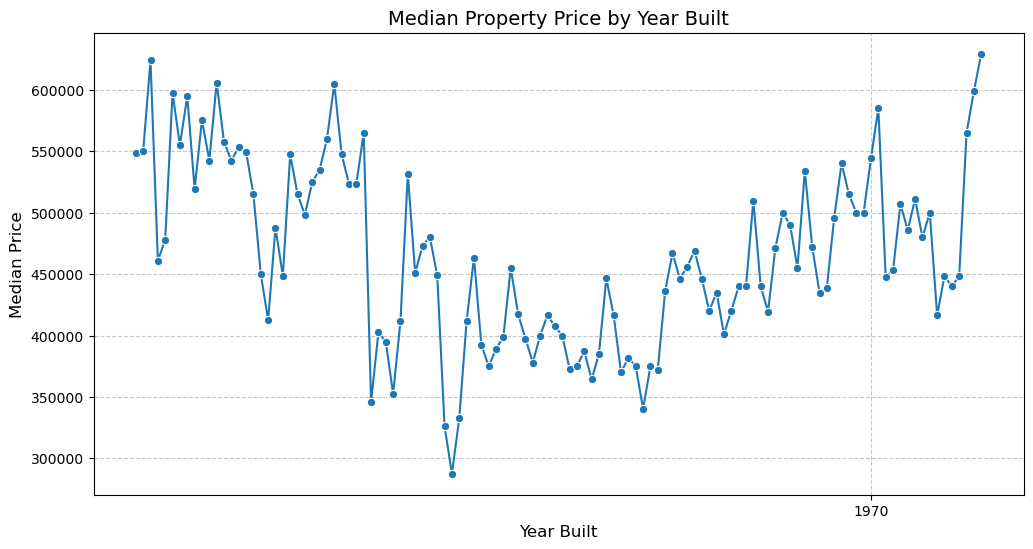

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.clf()

plt.figure(figsize=(12, 6))
sns.lineplot(data=median_prices, x='yr_built', y='price', marker='o')
plt.title('Median Property Price by Year Built', fontsize=14)
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Median Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## We can use pandas method corr() to find the feature other than price that us most correlated with price

In [43]:
correlation_matrix=df.corr(numeric_only = True)
price_correlation= correlation_matrix['price'].sort_values(ascending = False)
print(price_correlation)


price            1.000000
sqft_living      0.701917
grade            0.667951
sqft_above       0.605368
sqft_living15    0.585241
bathrooms        0.525906
view             0.393497
bedrooms         0.308787
lat              0.306692
waterfront       0.264306
floors           0.256804
yr_renovated     0.117855
sqft_lot         0.089876
sqft_lot15       0.082845
condition        0.036056
long             0.022036
zipcode         -0.053402
Name: price, dtype: float64


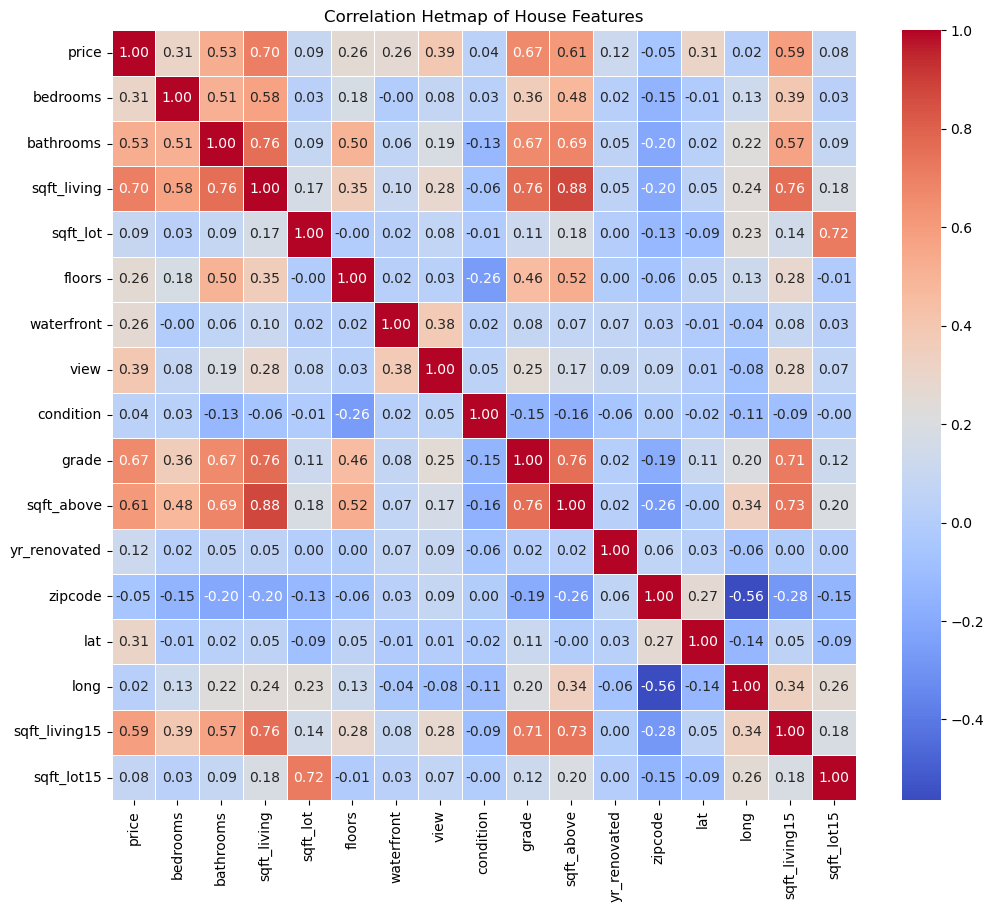

In [47]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths= 0.5)
plt.title('Correlation Hetmap of House Features')
plt.show()

## Checking for outliers
In EDA, an outlier is a data point that is significantly different from the remaining data. Think of it as the "weird" value—like a house priced at 10,000,000 in a neighborhood where the average is $300,000.

Detecting them is vital because they can heavily skew your mean and standard deviation, leading to misleading conclusions.

In [53]:
#count how many rows exceed thresholds

outliers= df[(df['bedrooms'] > 10) | (df['bathrooms'] > 5)]
print("Number of outliers:", outliers.shape[0])
print ("Percentage of dataset:", outliers.shape[0] / df.shape[0] * 100, "%")

Number of outliers: 45
Percentage of dataset: 0.2083622725378525 %


In [58]:
# remove rows with more than 10 bedroom
df= df[df['bedrooms'] <= 10]

In [60]:
# double check that no rows with > 10 bedroom
print(df['bedrooms'].max())

10


In [63]:
## count rows exceed threshold
bathroom_outliers= df[df['bathrooms'] > 5]
print("Number of outliers:", outliers.shape[0])
print ("Percentage of dataset:", outliers.shape[0] / df.shape[0] * 100, "%")

Number of outliers: 45
Percentage of dataset: 0.2083815698078259 %


In [64]:
# remove rows with more than 5 bathrooms
df= df[df['bathrooms'] <= 5]

In [65]:
# double check that no rows with > 5 bathrooms
print(df['bathrooms'].max())

5.0
